# Real-World Imprinting Analysis: GSE52576 Dataset"

Contributor: Dr. Hongjian Jin

## Overview

This vignette demonstrates imprintomeR on **GSE52576**, a real-world methylation dataset from the Gene Expression Omnibus (GEO). You will:

1. **Download** normalized beta values from GEO using GEOquery
2. **Create** an ImprintomeSet analysis-ready object
3. **Analyze** imprinting status across samples
4. **Visualize** results with all available plot types
5. **Interpret** biological patterns and aberrant imprinting

## Phase 1: Setup & Data Download

### Load libraries

In [3]:
library(imprintomeR)
library(GEOquery)
library(tidyverse)
library(ComplexHeatmap)
library(ggplot2)
library(knitr)


Attaching package: ‘imprintomeR’


The following object is masked from ‘package:base’:

    beta


Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'ci

### Download GSE52576 from GEO

GSE52576 is a publicly available dataset of	Genome-wide parent-of-origin DNA methylation analysis using Illumina 450K methylation arrays.


In [4]:
geo_gse <- "GSE52576"
message("Downloading ", geo_gse, " from GEO...")

tryCatch({
  gse <- getGEO(geo_gse, GSEMatrix = TRUE, AnnotGPL = TRUE, getGPL = FALSE)
  eset <- gse[[1]]  # Extract ExpressionSet object
  
  message("✓ Download successful")
  message("  Samples: ", ncol(eset))
  message("  Probes:  ", nrow(eset))
}, error = function(e) {
  stop("Failed to download ", geo_gse, ":\n", conditionMessage(e), 
       "\nCheck internet connection and GEO availability.")
})


Found 1 file(s)

GSE52576_series_matrix.txt.gz

✓ Download successful

  Samples: 28

  Probes:  485577



### Extract metadata and beta values


In [5]:
# Extract phenotype data (metadata)
pdata <- pData(eset)
message("Available metadata columns:")
print(colnames(pdata))

# Display sample information
message("\nSample overview:")
head(pdata[, c("geo_accession", "title", "source_name_ch1")], n = 3)

Available metadata columns:



 [1] "title"                   "geo_accession"          
 [3] "status"                  "submission_date"        
 [5] "last_update_date"        "type"                   
 [7] "channel_count"           "source_name_ch1"        
 [9] "organism_ch1"            "characteristics_ch1"    
[11] "characteristics_ch1.1"   "characteristics_ch1.2"  
[13] "molecule_ch1"            "extract_protocol_ch1"   
[15] "label_ch1"               "label_protocol_ch1"     
[17] "taxid_ch1"               "hyb_protocol"           
[19] "scan_protocol"           "description"            
[21] "data_processing"         "platform_id"            
[23] "contact_name"            "contact_laboratory"     
[25] "contact_department"      "contact_institute"      
[27] "contact_address"         "contact_city"           
[29] "contact_state"           "contact_zip/postal_code"
[31] "contact_country"         "supplementary_file"     
[33] "data_row_count"          "gender:ch1"             
[35] "health state:ch1"        


Sample overview:



,geo_accession,title,source_name_ch1
,<chr>,<chr>,<chr>
GSM1270013,GSM1270013,Brain 2,Adult Brain
GSM1270014,GSM1270014,Brain 1,Fetal Brain
GSM1270015,GSM1270015,Muscle,Muscle


### Format data for imprintomeR


In [6]:
# Extract beta values (methylation intensities, 0-1 scale)
beta_matrix <- exprs(eset)
message("Beta matrix dimensions: ", nrow(beta_matrix), " probes × ", 
        ncol(beta_matrix), " samples")
message("Beta range: [", round(min(beta_matrix, na.rm = TRUE), 3), ", ",
        round(max(beta_matrix, na.rm = TRUE), 3), "]")

# Create metadata data.frame compatible with imprintomeR
meta <- data.frame(
  Sample_Name = colnames(beta_matrix),
  Sample_Group = pdata$source_name_ch1,  # Disease status or tissue type
  Disease_Status = pdata$characteristics_ch1.1,  # Detailed phenotype
  stringsAsFactors = FALSE
)

Beta matrix dimensions: 485577 probes × 28 samples

Beta range: [0, 0.999]



In [7]:
# Clean up Sample_Group (shorten for readability)
meta$Sample_Group <- gsub("^.*: ", "", meta$Sample_Group)

message("\nMetadata created:")
message("Samples: ", nrow(meta))
print(table(meta$Sample_Group))

message("\nFirst few samples:")
head(meta, n = 3)


Metadata created:

Samples: 28




                      Adult Brain                       Fetal Brain 
                                1                                 1 
       human embryonic stem cells                 Hydatidiform mole 
                                4                                 4 
                       Leukocytes                             Liver 
                                5                                 1 
                           Muscle                          Pancreas 
                                1                                 1 
parthenogenetic activated oocytes                             Sperm 
                                4                                 2 
        Term placenta- fetal side 
                                4 



First few samples:



,Sample_Name,Sample_Group,Disease_Status
,<chr>,<chr>,<chr>
1,GSM1270013,Adult Brain,health state: Health tissue
2,GSM1270014,Fetal Brain,health state: Health tissue
3,GSM1270015,Muscle,health state: Health tissue


### Validate data integrity

In [8]:
# Check for missing values
pct_missing <- colSums(is.na(beta_matrix)) / nrow(beta_matrix) * 100
message("Missing values per sample:")
if (max(pct_missing) > 0) {
  print(head(sort(pct_missing, decreasing = TRUE)))
} else {
  message("  ✓ No missing values")
}

# Verify sample name alignment
if (all(colnames(beta_matrix) == meta$Sample_Name)) {
  message("✓ Sample names aligned between beta and metadata")
} else {
  stop("Sample name mismatch!")
}

Missing values per sample:



GSM1270022 GSM1270028 GSM1270025 GSM1270023 GSM1270024 GSM1270016 
 0.3222970  0.1690772  0.1550732  0.1412752  0.1348911  0.1175921 


✓ Sample names aligned between beta and metadata



## Phase 2: Load & Create ImprintomeSet

### Load data using imprintomeR utilities


In [9]:
# Use imprintomeR's LoadMetaBeta function to validate and intersect data
beta <- as.data.frame(beta_matrix)
beta <- cbind(NAME = rownames(beta), beta)
input <- LoadMetaBeta(meta, beta, probeset = NULL)

message("Loaded data:")
message("  Samples: ", ncol(input$beta))
message("  Probes:  ", nrow(input$beta))
message("  Metadata cols: ", paste(colnames(input$meta), collapse = ", "))

# Peek at data structure
message("\nBeta matrix (first 5 probes, 3 samples):")
print(round(input$beta[1:5, 1:3], 3))


	[meta dim: 28 x 3 ]
	[beta dim: 485577 x 29 ]
	[meta dim: 28 x 3 ]
	[beta dim: 485577 x 28 ]

Loaded data:

  Samples: 28

  Probes:  485577

  Metadata cols: Sample_Name, Sample_Group, Disease_Status


Beta matrix (first 5 probes, 3 samples):



           GSM1270013 GSM1270014 GSM1270015
cg00000029      0.786      0.770      0.580
cg00000108      0.930      0.933      0.835
cg00000109      0.840      0.863      0.845
cg00000165      0.103      0.104      0.087
cg00000236      0.904      0.912      0.836


### Create ImprintomeSet object


In [10]:
# Load probeset annotations
probesets <- readRDS(
  system.file("extdata", "probesets_hg19.rds", package = "imprintomeR")
)

# Create analysis-ready ImprintomeSet
x <- ImprintomeSet(
  beta = input$beta,
  meta = input$meta,
  probeset = probesets[["selected"]],  # Use all probes; will be subset by runImprintome
  genome = "hg19",
  assay = "450K"  # GSE52576 uses Illumina 450K (close to EPIC v1)
)

In [11]:
# Verify object structure
message("ImprintomeSet created:")
message("  Samples: ", ncol(beta(x)))
message("  Probes: ", nrow(beta(x)))
message("  Genome: ", x@genome)
message("  Assay: ", x@assay)
print(summary(x))

ImprintomeSet created:

  Samples: 28

  Probes: 485577

  Genome: hg19

  Assay: 450K



       Length         Class          Mode 
            1 ImprintomeSet            S4 


## Phase 3: Run Workflow & Compute Statistics

### Execute imprintomeR analysis


In [12]:
message("Running imprintome analysis...")
x <- runImprintome(x)
message("✓ Analysis complete")

# Extract results
res <- results(x)
message("\nResults available:")
print(names(res))

# Display analysis summary
message("\nAnalysis summary:")
status <- res$AnalyzeImprintStatus.selected
print(head(status,n=5))

Running imprintome analysis...




	[meta dim: 28 x 3 ]
	[beta dim: 485577 x 29 ]
	[meta dim: 28 x 3 ]
	[beta dim: 485577 x 28 ]
	[SubsetBeta] subset by probeset [query: 669; matched probes: 669 ]


✓ Analysis complete


Results available:



[1] "AnalyzeImprintStatus.selected"



Analysis summary:



           Sample_Name Sample_Group probeset paternal_median maternal_median
GSM1270013  GSM1270013  Adult Brain selected           0.545           0.541
GSM1270014  GSM1270014  Fetal Brain selected           0.542           0.546
GSM1270015  GSM1270015       Muscle selected           0.539           0.540
GSM1270016  GSM1270016     Pancreas selected           0.527           0.544
GSM1270017  GSM1270017        Liver selected           0.527           0.525
            pat_cons  mat_cons consistency   IDS Angle Mechanism Status
GSM1270013 0.7416667 0.7228682   0.7322674 0.061  42.5       ROI Normal
GSM1270014 0.7666667 0.7538760   0.7602713 0.063  47.7       ROI Normal
GSM1270015 0.6750000 0.7034884   0.6892442 0.056  46.3       ROI Normal
GSM1270016 0.5666667 0.6182171   0.5924419 0.051  58.4       ROI Normal
GSM1270017 0.6166667 0.6162791   0.6164729 0.037  43.4       ROI Normal
              Confidence
GSM1270013 High (Normal)
GSM1270014 High (Normal)
GSM1270015 High (Normal)
GSM127

### Compute per-group statistics


In [13]:
# Summarize by Sample_Group
message("\nImprinting status by group:")
print(table(status[,c("Sample_Group","Mechanism")]))


Imprinting status by group:



                                   Mechanism
Sample_Group                        Global-Hypo Mat-Gain Mat-Gain+Pat-Loss
  Adult Brain                                 0        0                 0
  Fetal Brain                                 0        0                 0
  human embryonic stem cells                  0        0                 0
  Hydatidiform mole                           0        0                 0
  Leukocytes                                  0        0                 1
  Liver                                       0        0                 0
  Muscle                                      0        0                 0
  Pancreas                                    0        0                 0
  parthenogenetic activated oocytes           0        1                 3
  Sperm                                       2        0                 0
  Term placenta- fetal side                   0        0                 0
                                   Mechanism
Sample_Gro

### Review key metrics


In [14]:
# Distribution of key imprinting metrics
message("IDS (Imprinting Defect Score) distribution:")
print(summary(status$IDS))

message("\nMechanism classification:")
print(table(status$Mechanism))

message("\nAngle (parental origin deviation) distribution:")
print(summary(status$Angle))

IDS (Imprinting Defect Score) distribution:



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.03400 0.05475 0.25050 0.25429 0.45200 0.60800 



Mechanism classification:




      Global-Hypo          Mat-Gain Mat-Gain+Pat-Loss Pat-Gain+Mat-Loss 
                2                 1                 4                 8 
              ROI 
               13 



Angle (parental origin deviation) distribution:



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  27.50   79.85  134.15  181.93  314.18  347.60 


## Phase 4: Visualizations — Complete Gallery


In [15]:
sample_id_1 <- colnames(beta(x))[2]
message("Representative sample for single-sample plots: ", sample_id_1)

x <- runImprintomeVisualizations(
  x,
  probeset = "selected",
  sample_id = sample_id_1,
  prefix = "GSE52576",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)

attr(x, "visualization_manifest")
names(plots(x))

Representative sample for single-sample plots: GSM1270014

Generating polar ...
 stored

Generating beeswarm_origin ...
 stored

Generating mirror_density ...



	[SubsetBeta] subset by probeset [query: 669; matched probes: 669 ]


 stored

Generating heatmap_by_probe ...
 stored

Generating heatmap_by_gene ...
 stored

Generating radar ...
 stored

Generating beeswarm_chr ...
 stored

Generating rainfall ...
 stored



plot_type,name,status,file,message
<chr>,<chr>,<chr>,<chr>,<chr>
polar,polar.selected,stored,,
beeswarm_origin,beeswarm_origin.selected,stored,,
mirror_density,mirror_density.selected,stored,,
heatmap_by_probe,heatmap.selected,stored,,
heatmap_by_gene,heatmap_by_gene.selected,stored,,
radar,radar.GSM1270014,stored,,
beeswarm_chr,beeswarm_chr.GSM1270014,stored,,
rainfall,rainfall.GSM1270014,stored,,


[1] "polar.selected"           "beeswarm_origin.selected"
[3] "mirror_density.selected"  "heatmap.selected"        
[5] "heatmap_by_gene.selected" "radar.GSM1270014"        
[7] "beeswarm_chr.GSM1270014"  "rainfall.GSM1270014"

### Display selected stored plots

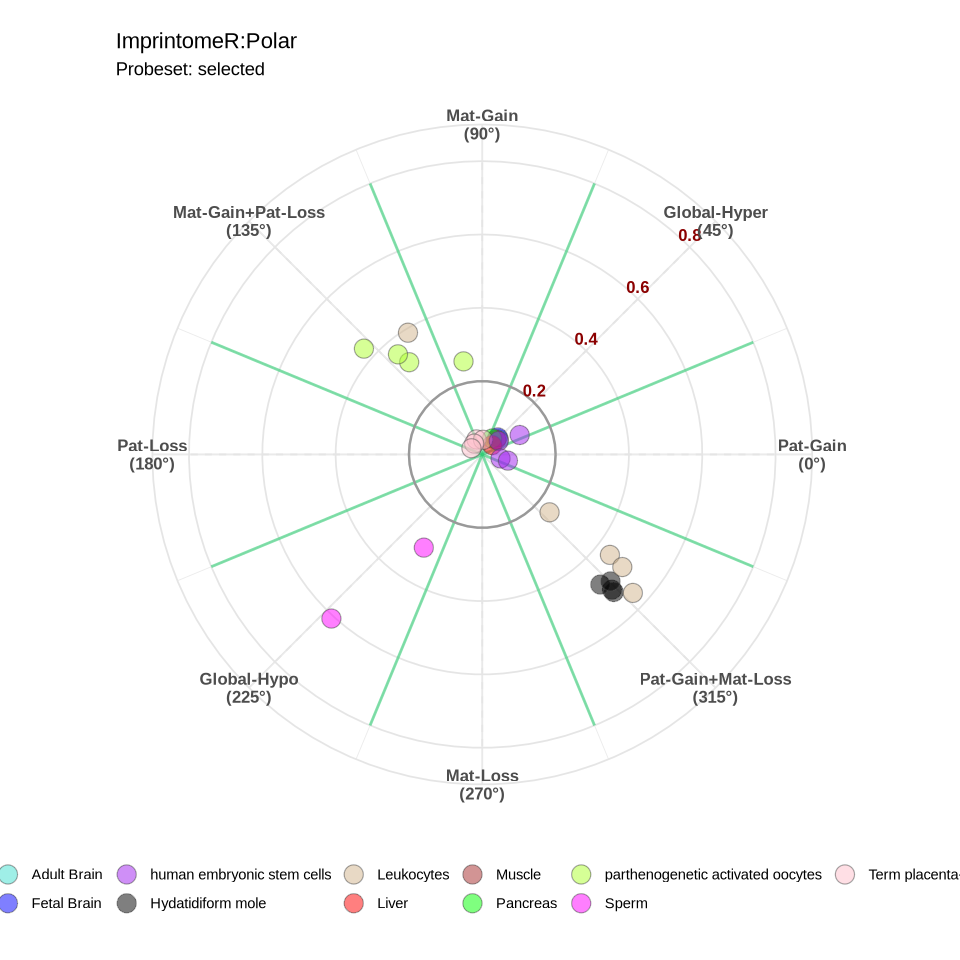

In [16]:
if (!is.null(plots(x)[["polar.selected"]])) {
  options(repr.plot.width = 8, repr.plot.height = 8)
  print(plots(x)[["polar.selected"]])
}


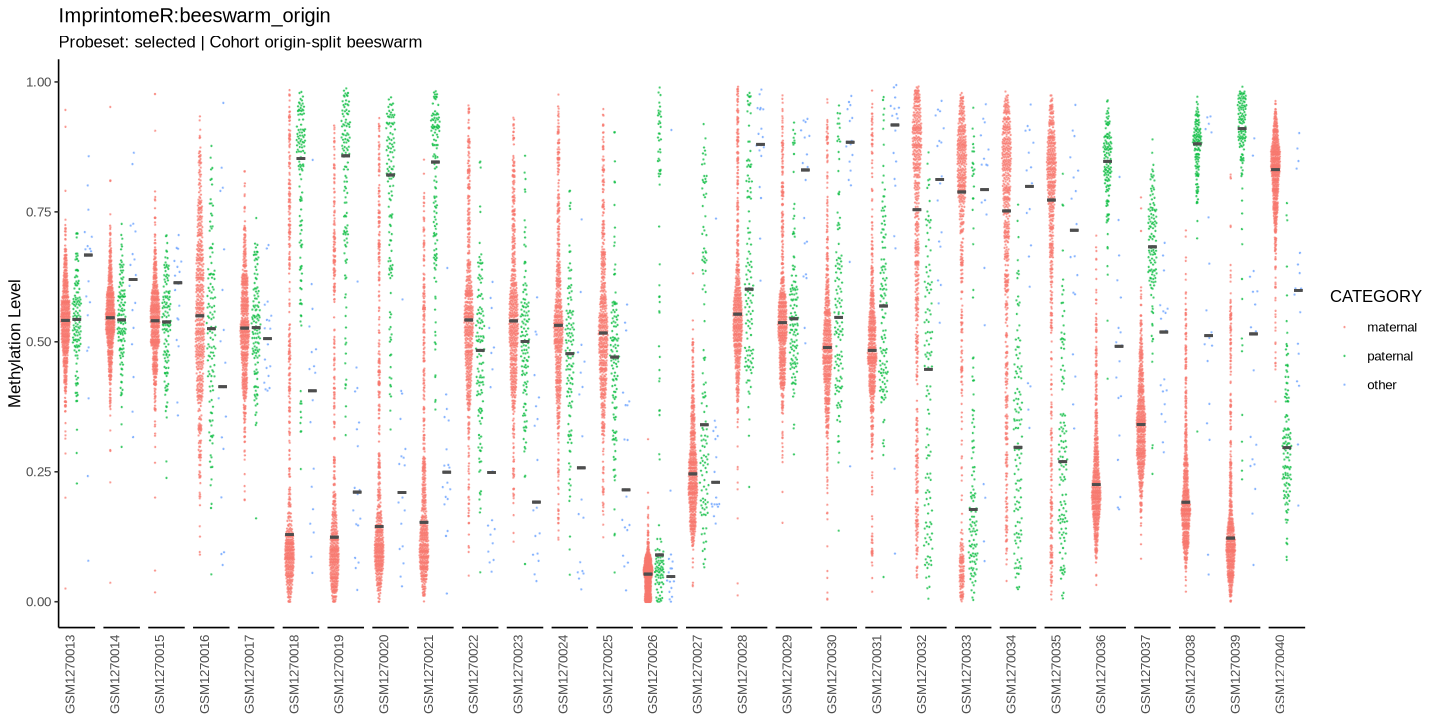

In [17]:
if (!is.null(plots(x)[["beeswarm_origin.selected"]])) {
   options(repr.plot.width = 12, repr.plot.height = 6)
  print(plots(x)[["beeswarm_origin.selected"]])
}

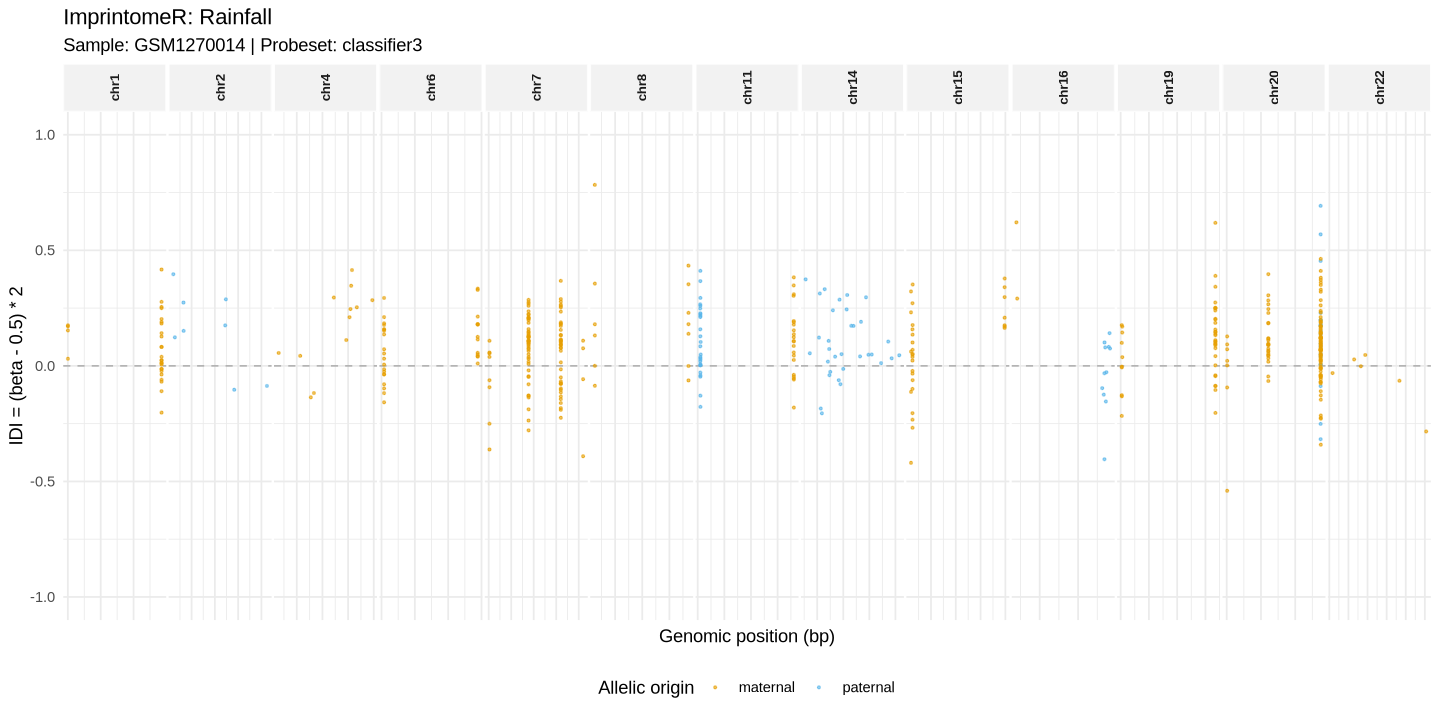

In [18]:
rainfall_name <- grep("^rainfall\\.", names(plots(x)), value = TRUE)[1]
if (!is.na(rainfall_name)) {
    options(repr.plot.width = 12, repr.plot.height = 6)
  print(plots(x)[[rainfall_name]])
}

### Visualizations by plot_type

The workflow helper can also run one plot backend at a time by setting `plot_types` explicitly.


### Plot 1: Polar scatter (IDS vs Angle)
The **polar plot** is the primary visualization—it shows each sample's imprinting deviation in 2D space, colored by mechanism classification.


Generating polar ...
 stored



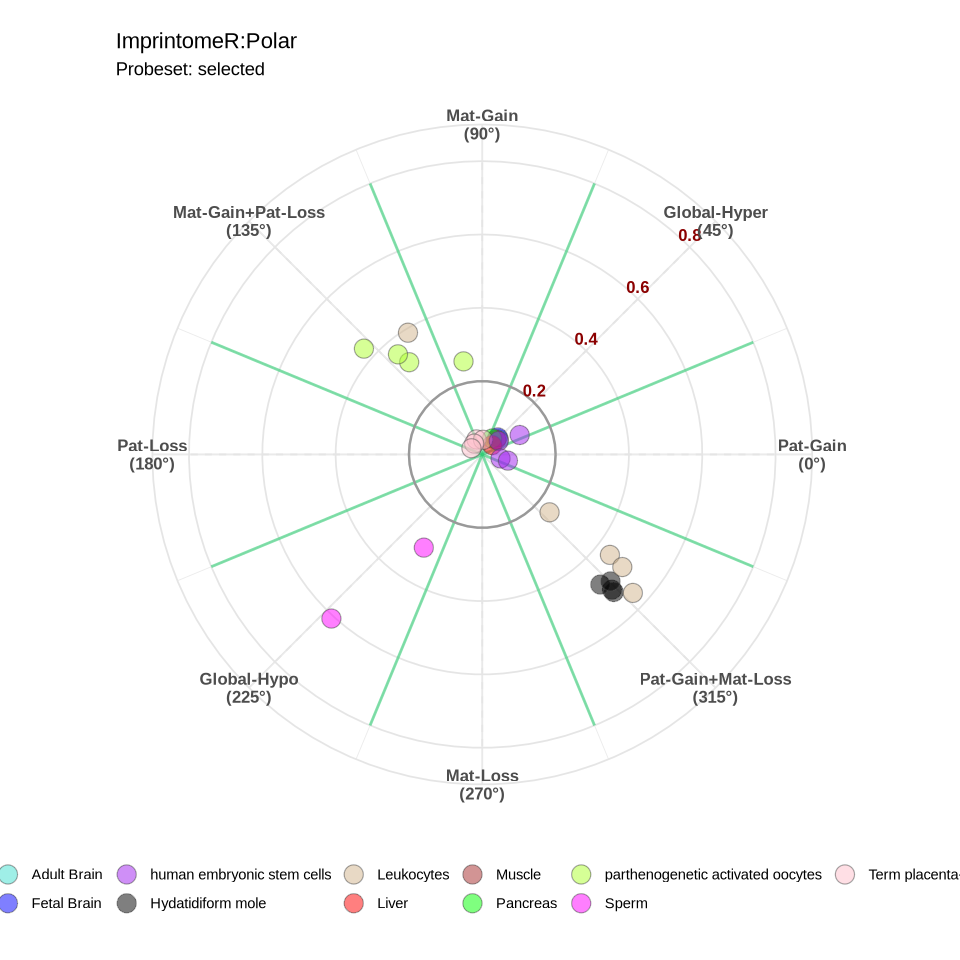

In [19]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "polar",
  probeset = "selected",
  result_name = "AnalyzeImprintStatus.selected",
  colorColumn = "Sample_Group",
  prefix = "GSE52576_polar",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
options(repr.plot.width = 8, repr.plot.height = 8)
print(plots(x)[["polar.selected"]])

### Plot 2: Beeswarm by origin (cohort-level methylation)

The **beeswarm plot** shows methylation distribution for each sample, faceted by parental origin (paternal vs maternal imprinting).


Generating beeswarm_origin ...
 stored



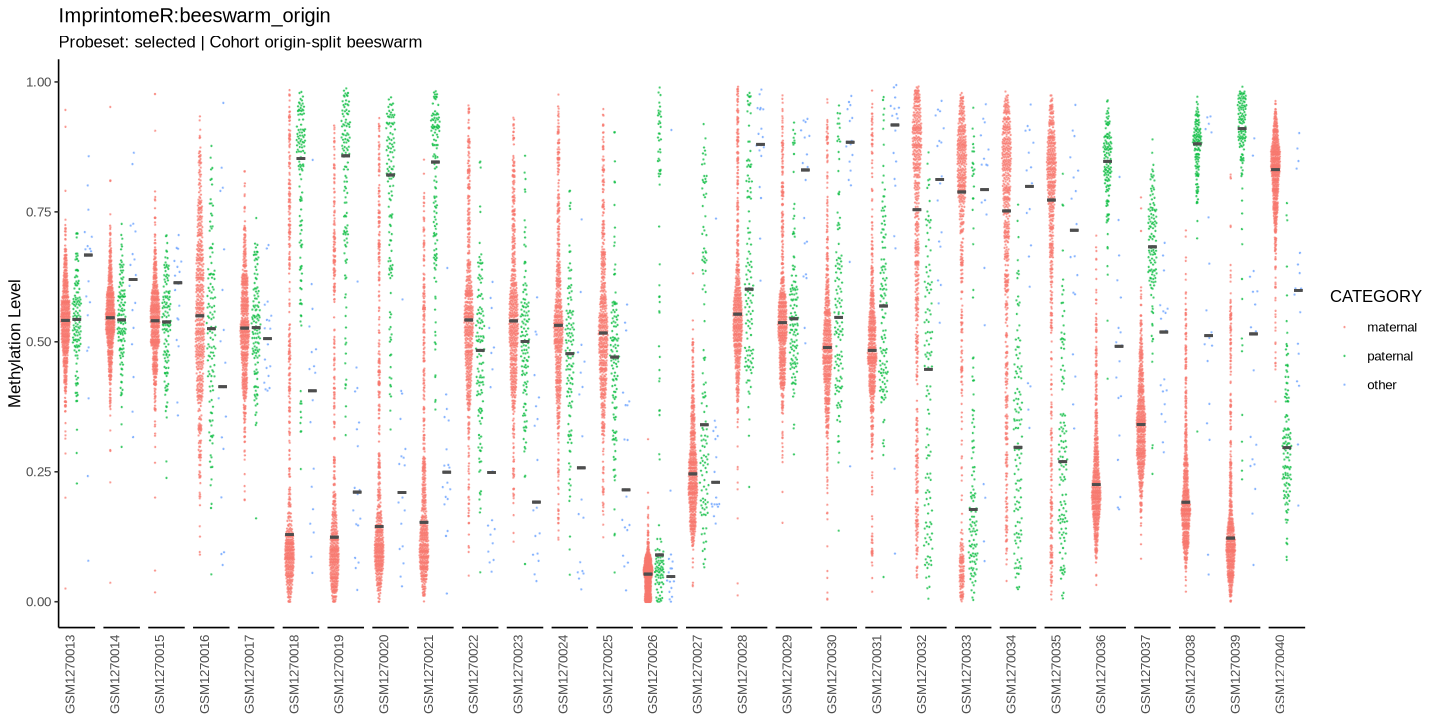

In [20]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "beeswarm_origin",
  probeset = "selected",
  SAMPLEID = "Sample_Name",
  prefix = "GSE52576_beeswarm_origin",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
options(repr.plot.width = 12, repr.plot.height = 6)
print(plots(x)[["beeswarm_origin.selected"]])

### Plot 3: Mirror density 

Generating mirror_density ...



	[SubsetBeta] subset by probeset [query: 669; matched probes: 669 ]


 stored



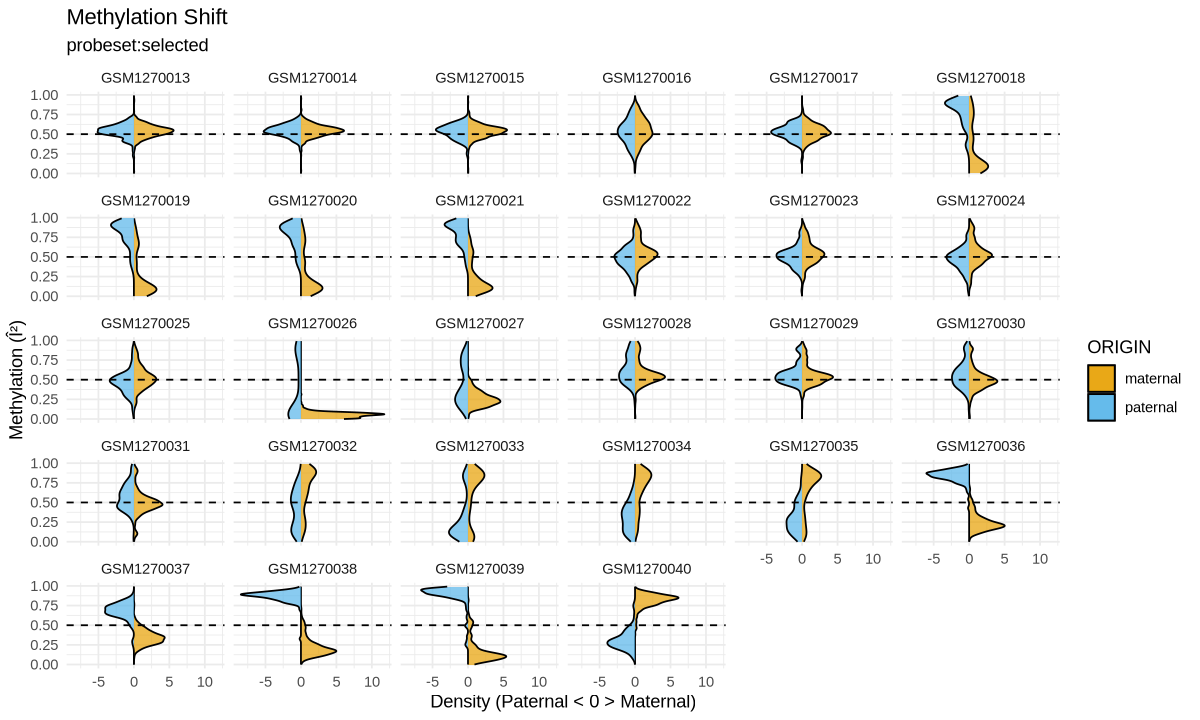

In [21]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "mirror_density",
  probeset = "selected",
  prefix = "GSE52576_mirror_density",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
options(repr.plot.width = 10, repr.plot.height = 6)
print(plots(x)[["mirror_density.selected"]])

### Plot 4: Beta heatmap (methylation by probeset)

The **heatmap** shows normalized methylation levels (beta values) across all probes in probeset and samples, organized by Sample_Group.


Generating heatmap_by_probe ...
 stored



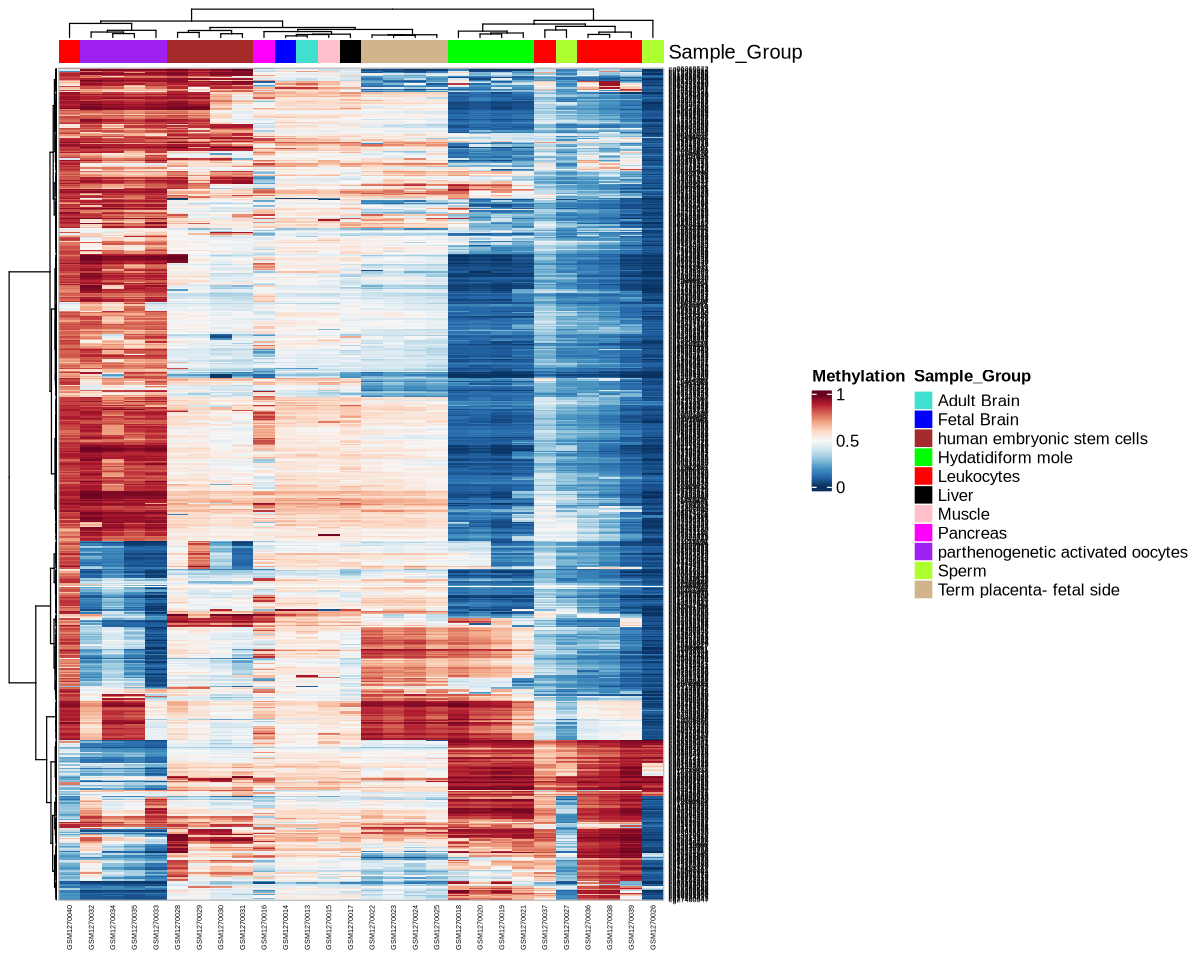

In [22]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "heatmap_by_probe",
  probeset = "selected",
  SAMPLEID = "Sample_Name",
  annoColumn = "Sample_Group",
  prefix = "GSE52576_heatmap_by_probe",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
options(repr.plot.width = 10, repr.plot.height = 8)
print(plots(x)[["heatmap.selected"]])

### Plot 5: Beta heatmap_by_gene (aggregates probes to gene level)


Generating heatmap_by_gene ...
 stored



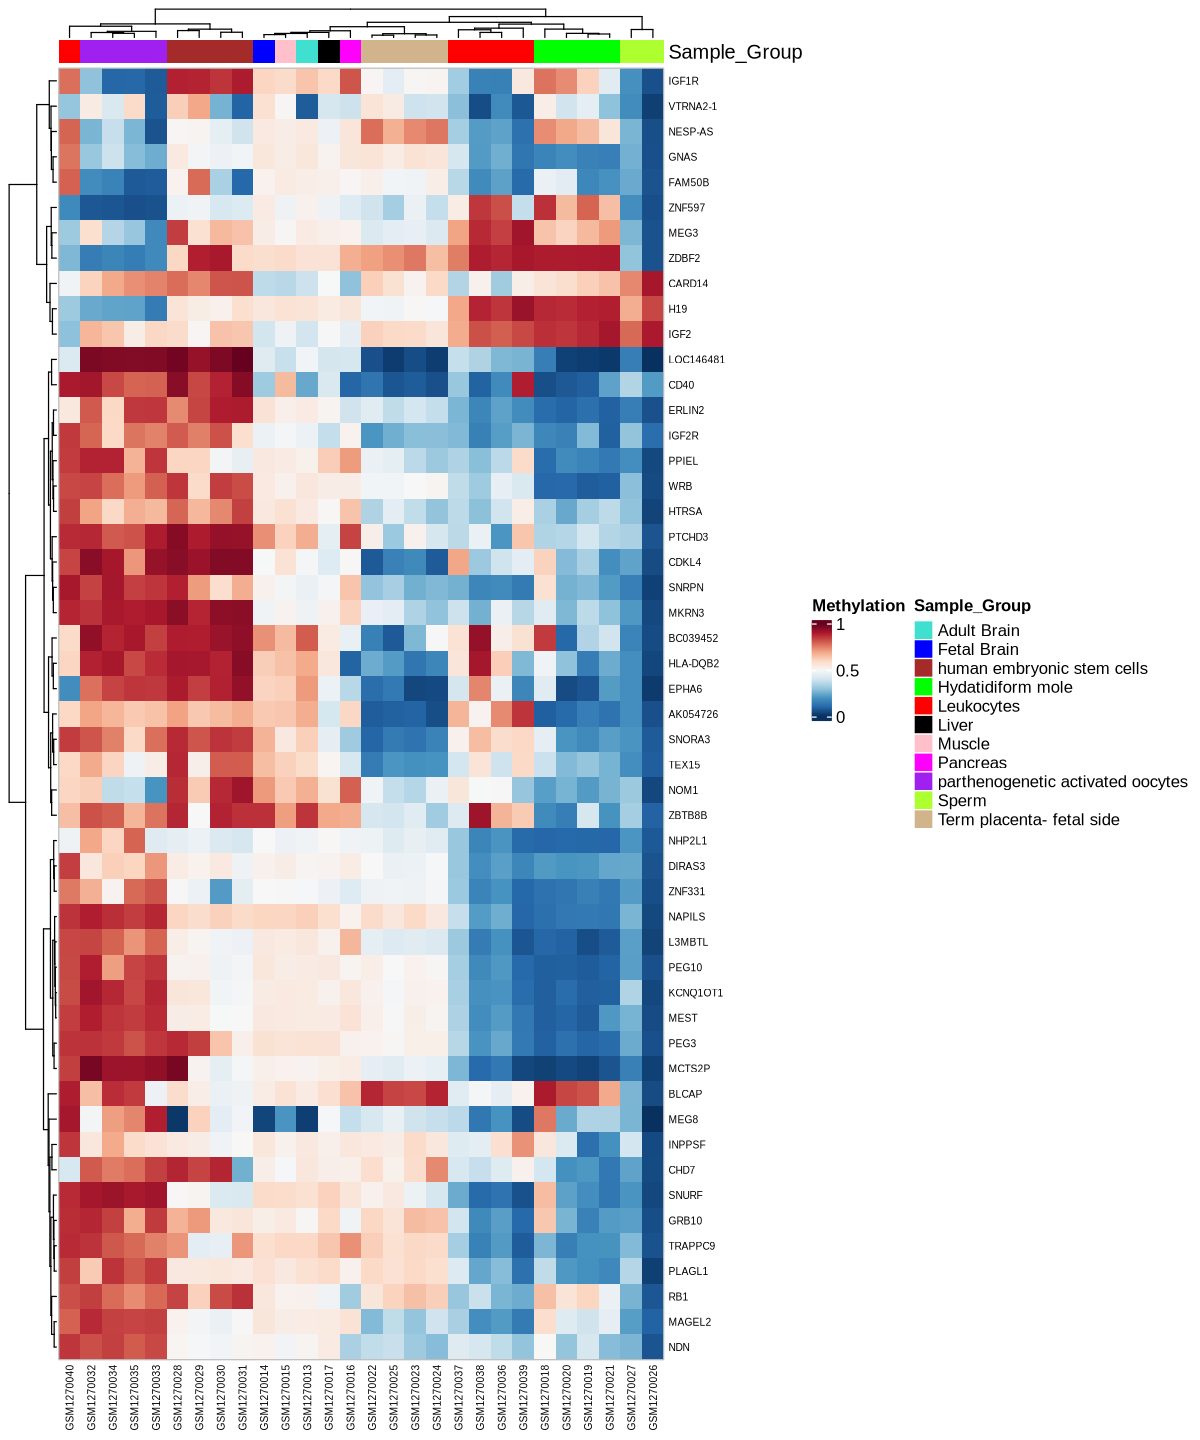

In [23]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "heatmap_by_gene",
  probeset = "selected",
  SAMPLEID = "Sample_Name",
  annoColumn = "Sample_Group",
  clusterRows = TRUE,
  clusterColumns = TRUE,
  prefix = "GSE52576_heatmap_by_gene",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
options(repr.plot.width = 10, repr.plot.height = 12)
print(plots(x)[["heatmap_by_gene.selected"]])

### Plot 6: Radar plot (multi-dimensional sample summary)

The **radar plot** displays a single sample's imprinting profile across multiple dimensions (IDS, Angle, IDI summary).


Generating radar ...
 stored



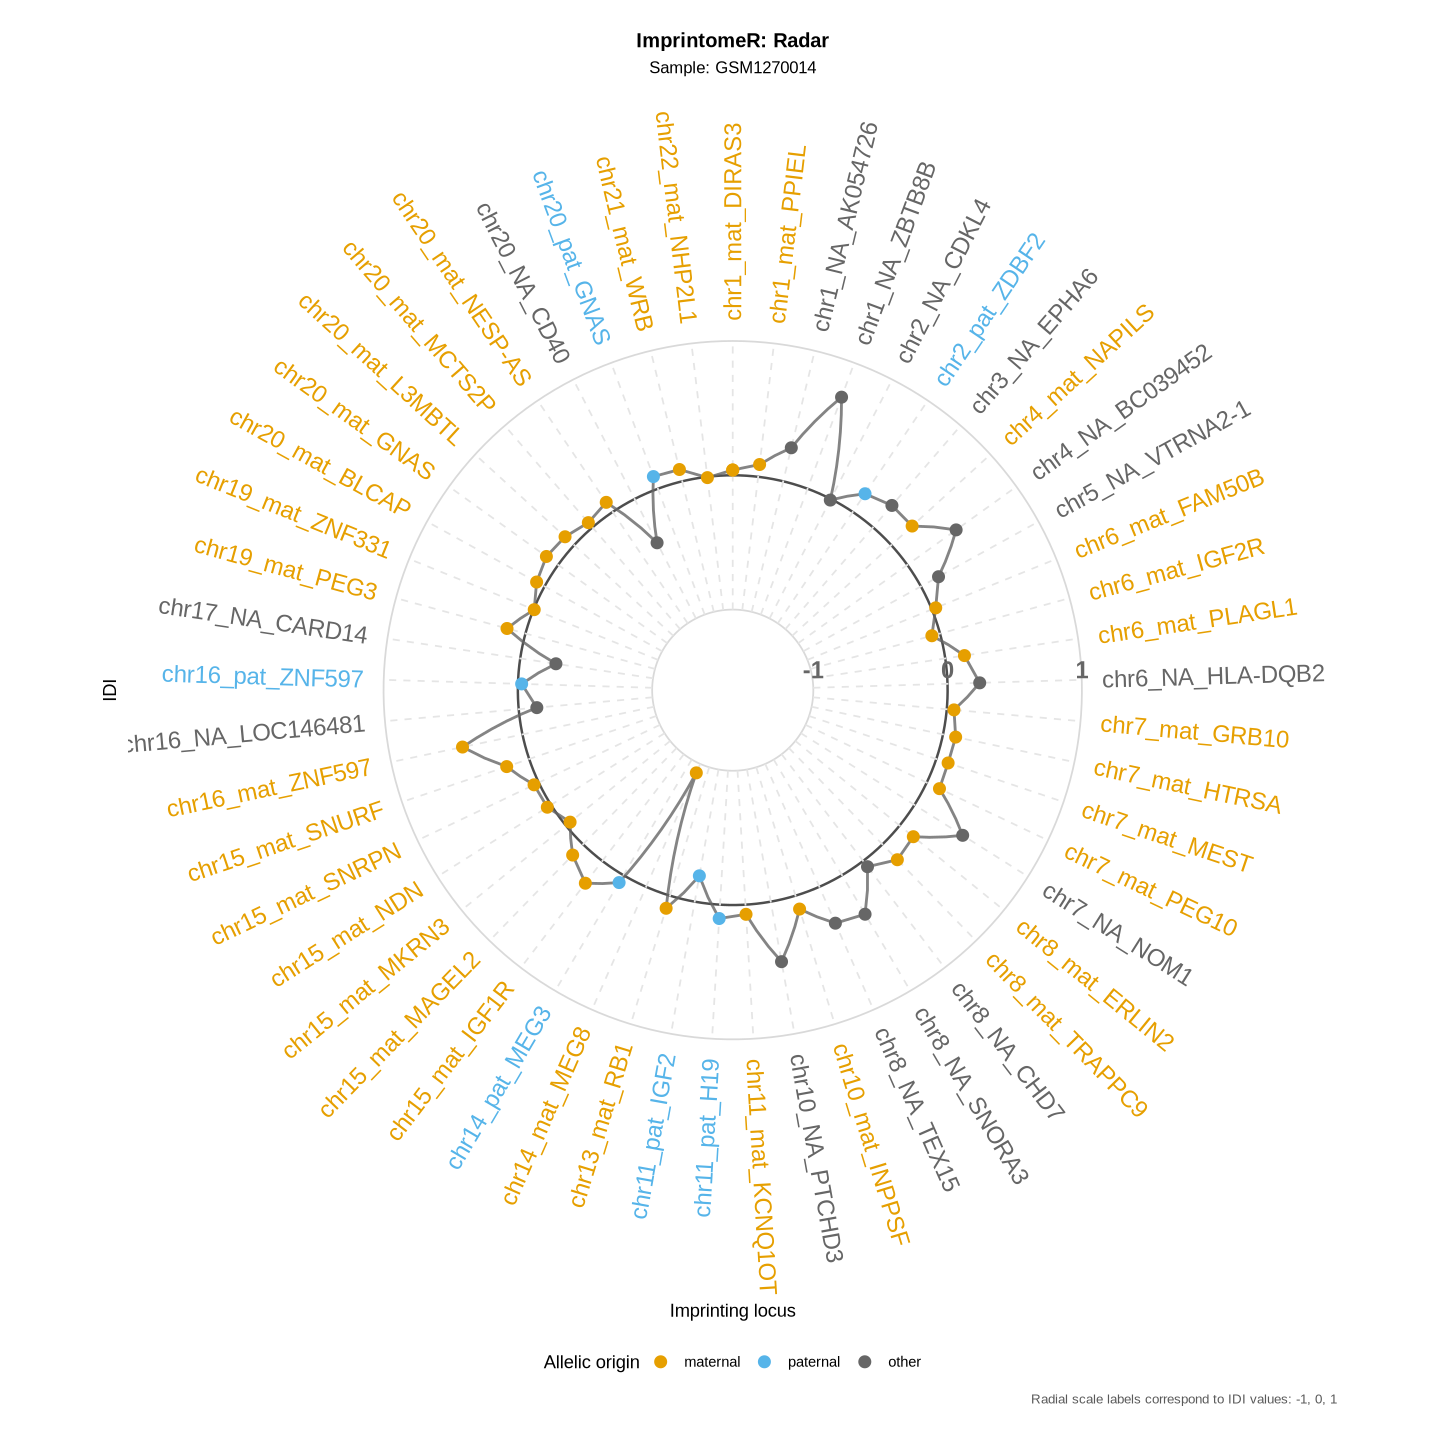

In [24]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "radar",
  probeset = "selected",
  sample_id = sample_id_1,
  prefix = "GSE52576_radar",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
radar_name <- grep("^radar\\.", names(plots(x)), value = TRUE)[1]
if (!is.na(radar_name)) {
  options(repr.plot.width = 12, repr.plot.height = 12)
  print(plots(x)[[radar_name]])
}


- GSM1270035 # maternal UPD

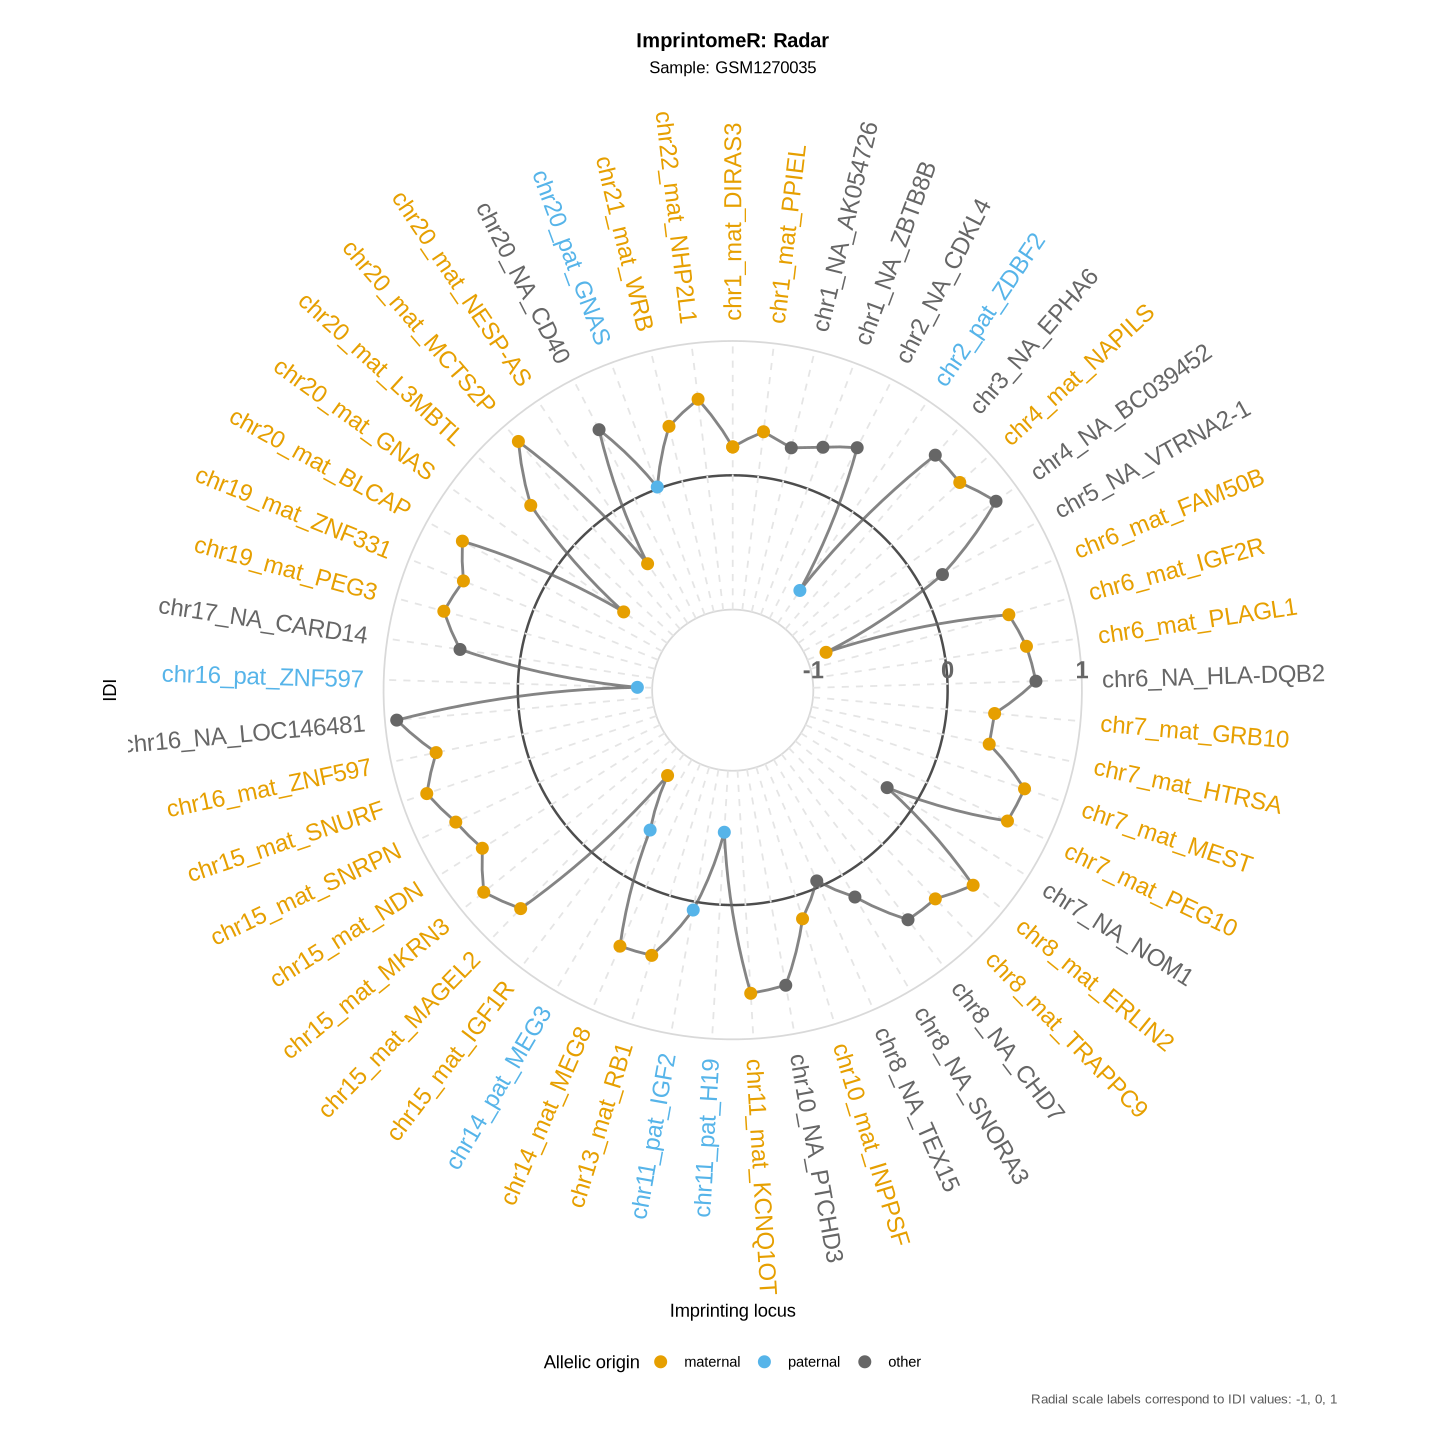

In [76]:
p_radar <- plot(
  x,
  plot_type = "radar",
  sample_id = "GSM1270035",
  probeset = "selected",
  outFile = NULL
)
options(repr.plot.width = 12, repr.plot.height = 12) 
print(p_radar)

- GSM1270037 # paternal UPD

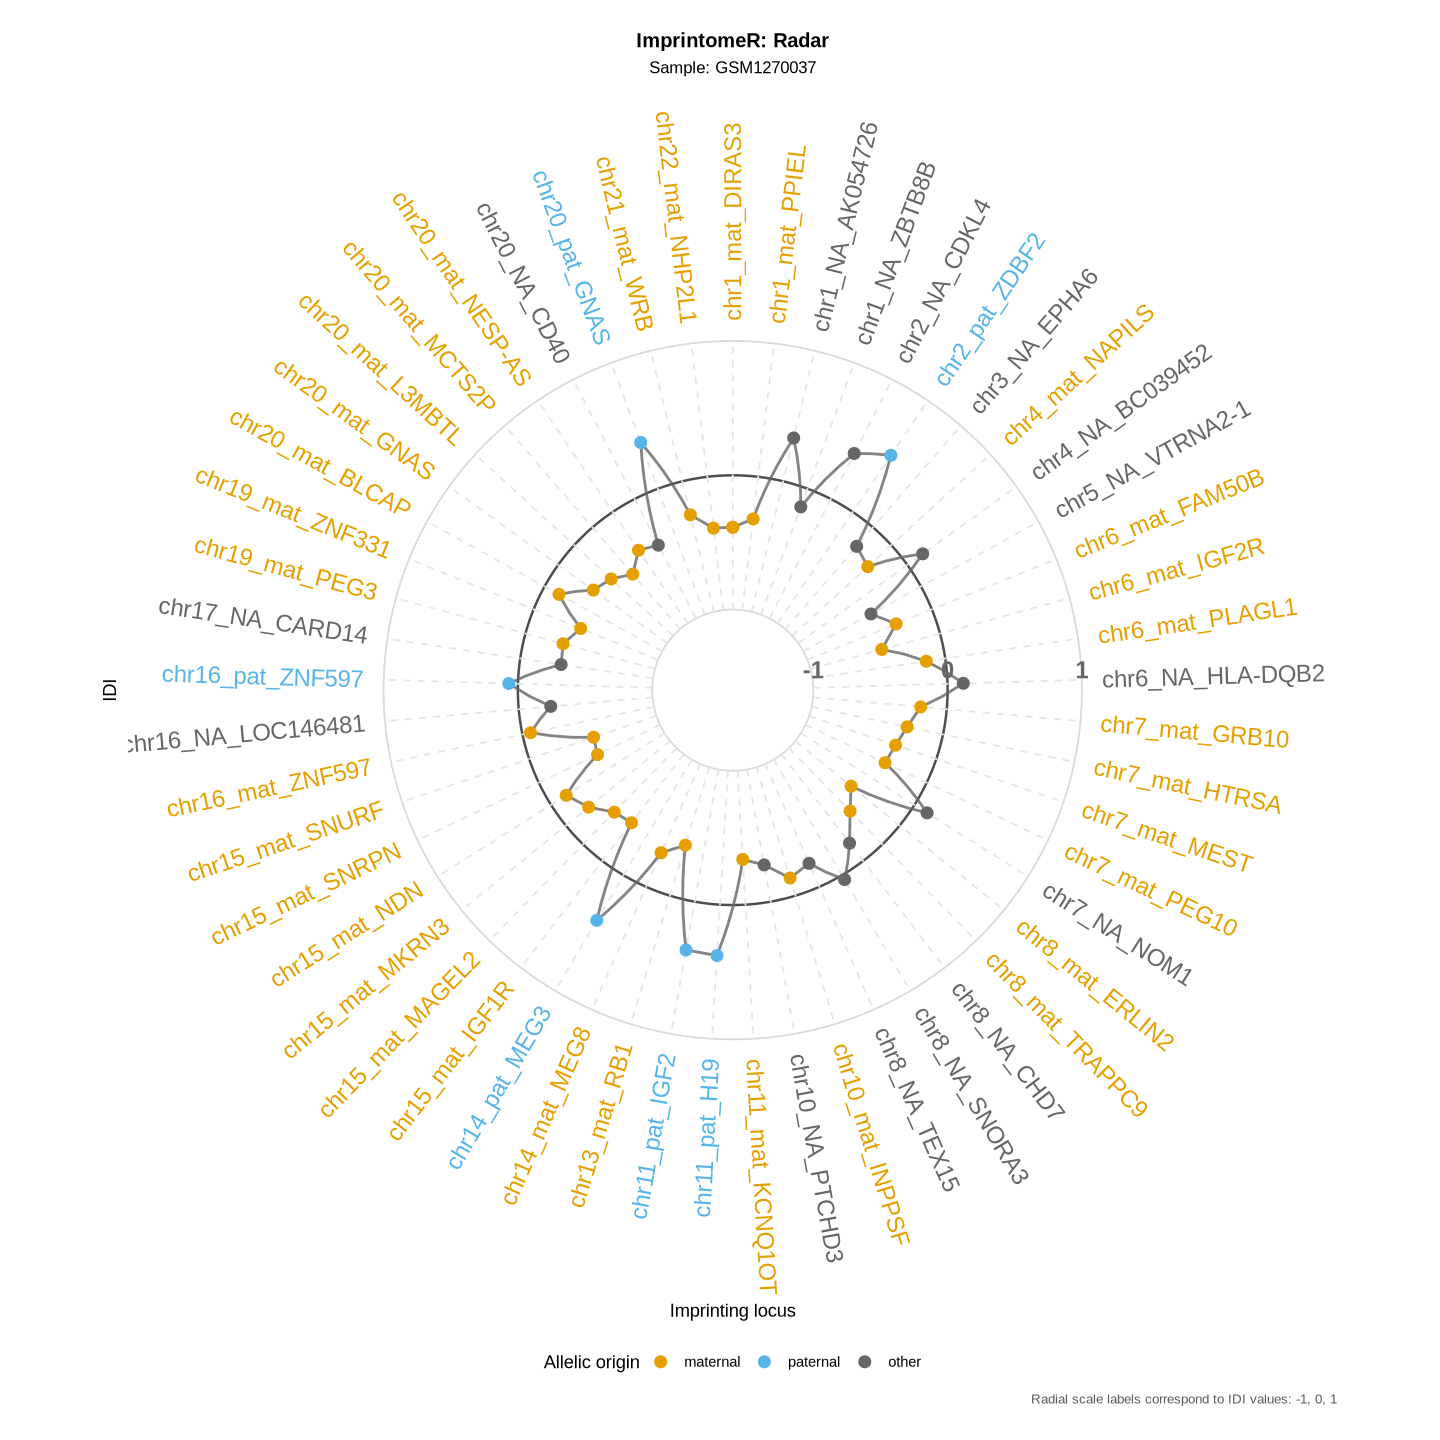

In [77]:
p_radar <- plot(
  x,
  plot_type = "radar",
  sample_id = "GSM1270037",
  probeset = "selected",
  outFile = NULL
)
options(repr.plot.width = 12, repr.plot.height = 12) 
print(p_radar)

### Plot 7: Beeswarm by chromosome (spatially organized)
The **chromosome beeswarm plot** shows methylation distribution for a single sample, faceted by chromosome location of imprinted sites.


In [87]:
p_beeswarm_chr_35 <- plot(
  x,
  plot_type = "beeswarm_chr",
  sample_id = "GSM1270035",
  outFile = NULL
)
p_beeswarm_chr_37 <- plot(
  x,
  plot_type = "beeswarm_chr",
  sample_id = "GSM1270037",
  outFile = NULL
)

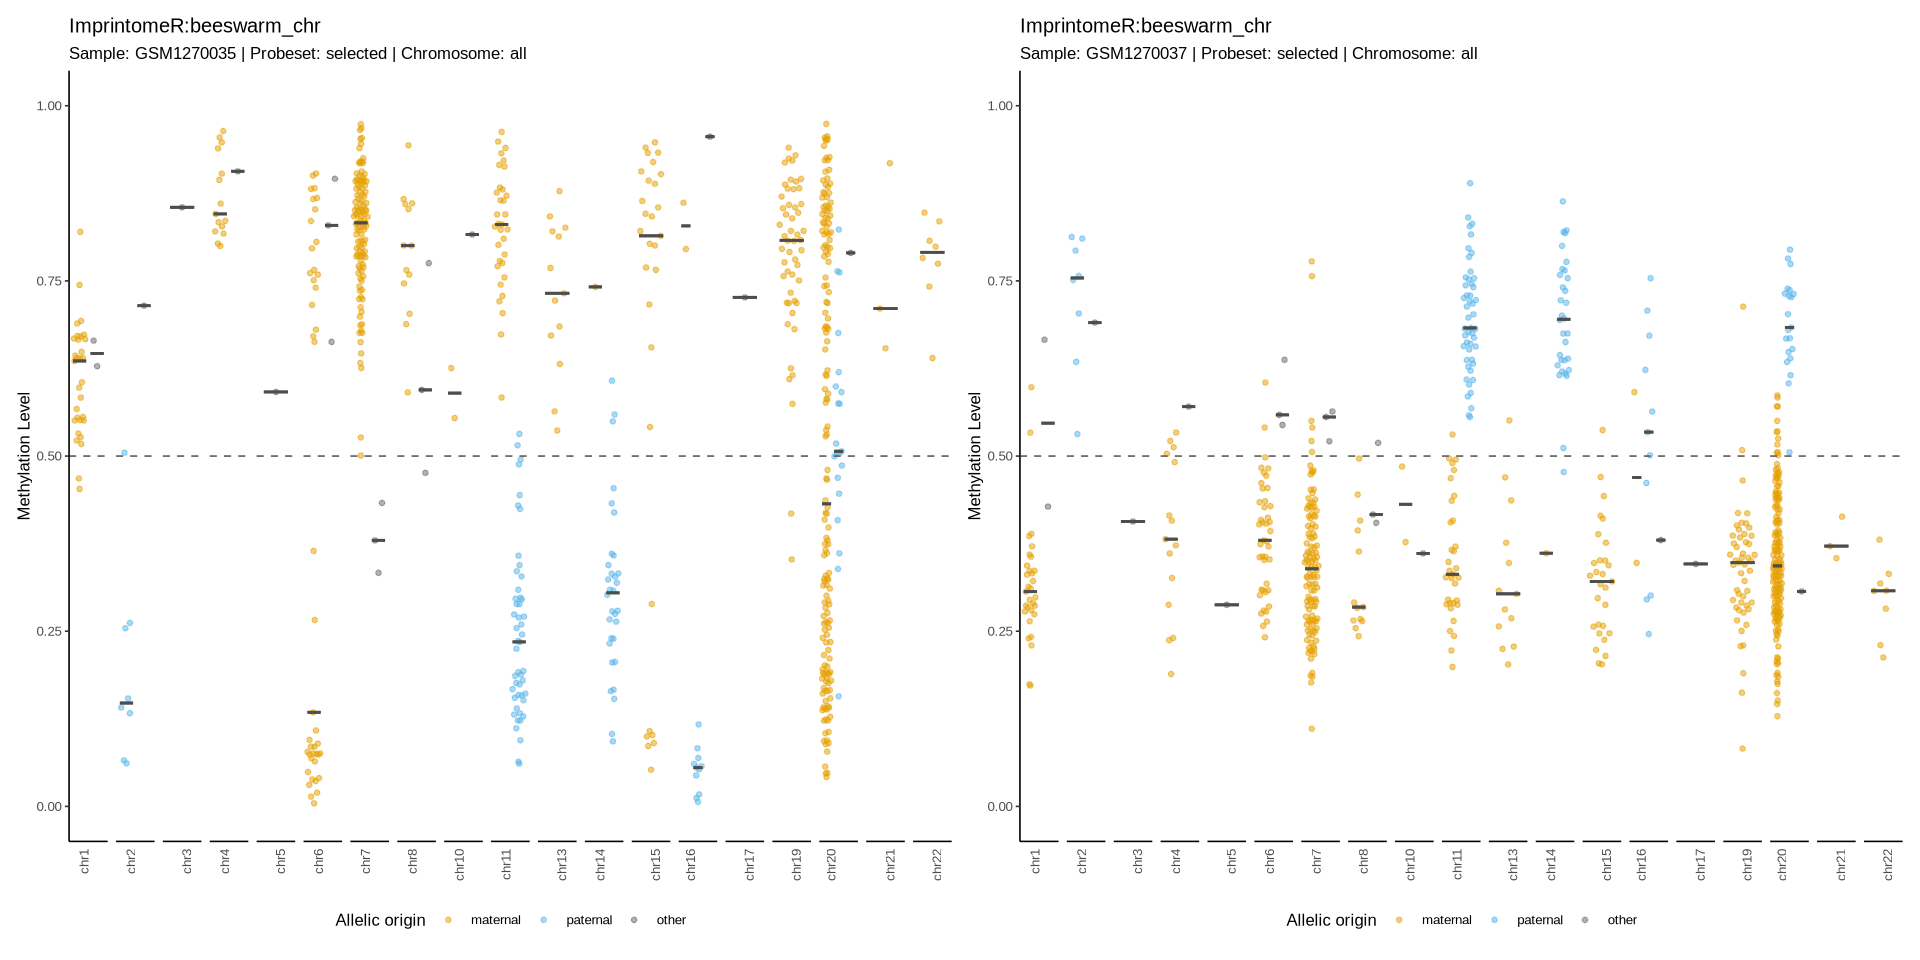

In [88]:
library(patchwork)
options(repr.plot.width = 16, repr.plot.height = 8) 
print(p_beeswarm_chr_35 + p_beeswarm_chr_37 + plot_layout(nrow = 1))

### Plot 8: Rainfall plot (sample-level detail)

The **rainfall plot** shows methylation deviations (IDI) across genomic positions for a single representative sample. Select sample 2 for demonstration:


Generating rainfall ...
 stored



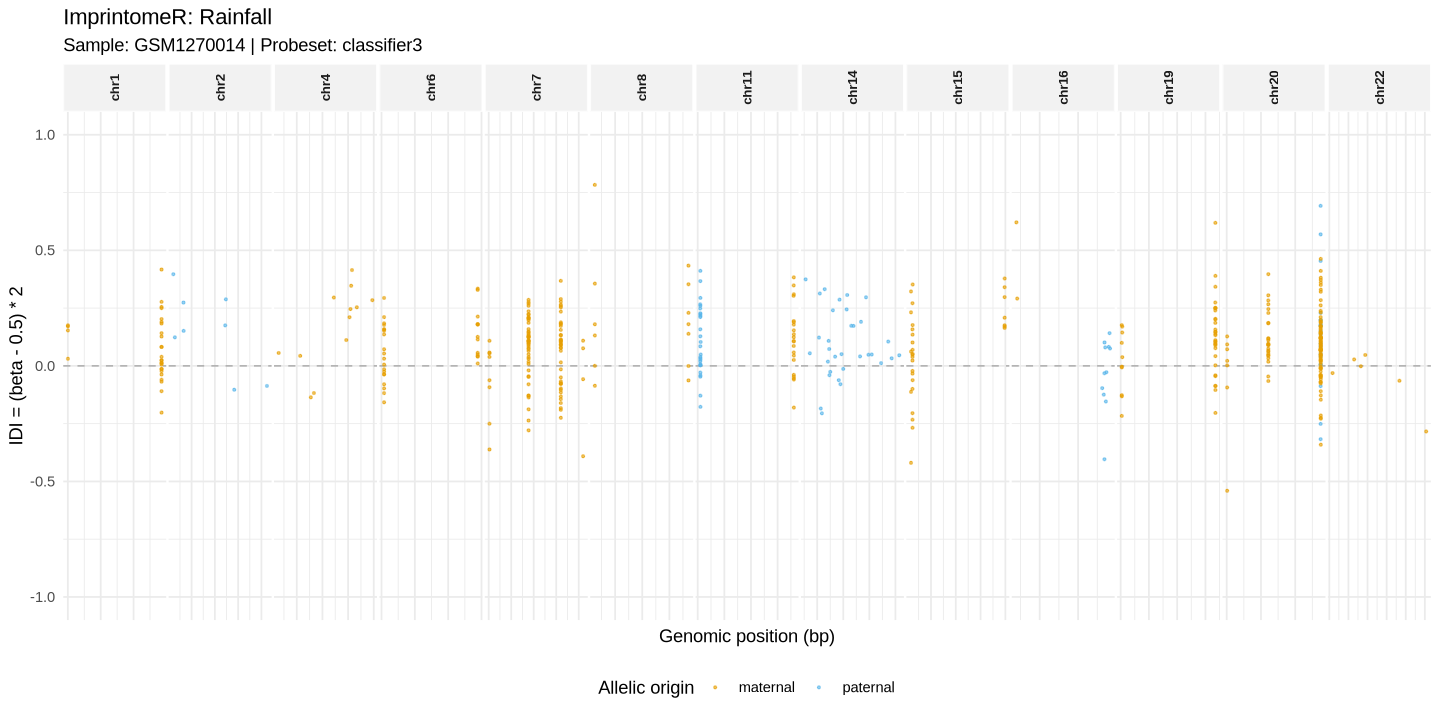

In [25]:
x <- runImprintomeVisualizations(
  x,
  plot_types = "rainfall",
  sample_id = sample_id_1,
  rainfall_probeset = "classifier3",
  prefix = "GSE52576_rainfall",
  store_plots = TRUE,
  save_plots = FALSE,
  verbose = TRUE
)
rainfall_name <- grep("^rainfall\\.", names(plots(x)), value = TRUE)[1]
if (!is.na(rainfall_name)) {
  options(repr.plot.width = 12, repr.plot.height = 6)
  print(plots(x)[[rainfall_name]])
}


## Phase 5: Results Interpretation & Case Study

### Summary statistics

In [50]:
res <- results(x)
status <- res$AnalyzeImprintStatus.selected
normal_n <- sum(status$Status %in% "Normal", na.rm = TRUE)
total_n <- nrow(status)
normal_pct <- normal_n / total_n * 100
abnormal_pct <- 100 - normal_pct

message("=== OVERALL IMPRINTING SUMMARY ===")
message(sprintf("Normal imprinting:   %6.1f%% (%d/%d samples)",
                normal_pct, normal_n, total_n))
message(sprintf("Altered imprinting:  %6.1f%% (%d/%d samples)",
                abnormal_pct, total_n - normal_n, total_n))

message("\n=== BY SAMPLE GROUP ===")
if ("Sample_Group" %in% colnames(status)) {
  for (group in unique(status$Sample_Group)) {
    idx <- status$Sample_Group == group
    n <- sum(idx, na.rm = TRUE)
    normal <- sum(status$Status[idx] == "Normal", na.rm = TRUE)
    message(sprintf("%20s: %d samples, %d normal (%.1f%%)",
                    group, n, normal, 100 * normal / n))
  }
} else {
  message("Sample_Group column not available in status table.")
}

=== OVERALL IMPRINTING SUMMARY ===

Normal imprinting:     46.4% (13/28 samples)

Altered imprinting:    53.6% (15/28 samples)


=== BY SAMPLE GROUP ===

         Adult Brain: 1 samples, 1 normal (100.0%)

         Fetal Brain: 1 samples, 1 normal (100.0%)

              Muscle: 1 samples, 1 normal (100.0%)

            Pancreas: 1 samples, 1 normal (100.0%)

               Liver: 1 samples, 1 normal (100.0%)

   Hydatidiform mole: 4 samples, 0 normal (0.0%)

Term placenta- fetal side: 4 samples, 4 normal (100.0%)

               Sperm: 2 samples, 0 normal (0.0%)

human embryonic stem cells: 4 samples, 4 normal (100.0%)

parthenogenetic activated oocytes: 4 samples, 0 normal (0.0%)

          Leukocytes: 5 samples, 0 normal (0.0%)



### Identify samples with altered imprinting


In [51]:
abnormal <- status %>% filter(!Status %in% "Normal")
sample_col <- intersect(c("Sample_Name", "Sample_ID"), colnames(status))[1]

if (nrow(abnormal) > 0) {
  message("=== ALTERED IMPRINTING SAMPLES ===")
  message("Sample count: ", nrow(abnormal))
  cols_to_show <- c(sample_col, intersect("Sample_Group", colnames(abnormal)),
                    "Status", "IDS", "Angle")
  print(abnormal %>% select(all_of(cols_to_show)) %>% head(n = 12))
} else {
  message("All samples show normal imprinting patterns by the selected IDS cutoff.")
}


=== ALTERED IMPRINTING SAMPLES ===

Sample count: 15



           Sample_Name                      Sample_Group                Status
GSM1270018  GSM1270018                 Hydatidiform mole Imprinting Alteration
GSM1270019  GSM1270019                 Hydatidiform mole Imprinting Alteration
GSM1270020  GSM1270020                 Hydatidiform mole Imprinting Alteration
GSM1270021  GSM1270021                 Hydatidiform mole Imprinting Alteration
GSM1270026  GSM1270026                             Sperm Imprinting Alteration
GSM1270027  GSM1270027                             Sperm Imprinting Alteration
GSM1270032  GSM1270032 parthenogenetic activated oocytes Imprinting Alteration
GSM1270033  GSM1270033 parthenogenetic activated oocytes Imprinting Alteration
GSM1270034  GSM1270034 parthenogenetic activated oocytes Imprinting Alteration
GSM1270035  GSM1270035 parthenogenetic activated oocytes Imprinting Alteration
GSM1270036  GSM1270036                        Leukocytes Imprinting Alteration
GSM1270037  GSM1270037                        Leukoc

### Phenotype-imprinting associations

In [52]:
if ("Sample_Group" %in% colnames(status) && length(unique(status$Sample_Group)) > 1) {
  message("Cross-tabulation: Sample_Group vs Imprinting Status")
  tbl <- table(status$Sample_Group, status$Status)
  print(tbl)

  group_summary <- status %>%
    group_by(Sample_Group, Status) %>%
    summarise(
      n = n(),
      median_IDS = median(IDS, na.rm = TRUE),
      median_Angle = median(Angle, na.rm = TRUE),
      .groups = "drop"
    )
  print(group_summary)
} else {
  message("Sample_Group is unavailable or has one level; skipping group cross-tabulation.")
}

Cross-tabulation: Sample_Group vs Imprinting Status



                                   
                                    Imprinting Alteration Normal
  Adult Brain                                           0      1
  Fetal Brain                                           0      1
  human embryonic stem cells                            0      4
  Hydatidiform mole                                     4      0
  Leukocytes                                            5      0
  Liver                                                 0      1
  Muscle                                                0      1
  Pancreas                                              0      1
  parthenogenetic activated oocytes                     4      0
  Sperm                                                 2      0
  Term placenta- fetal side                             0      4
# A tibble: 11 × 5
   Sample_Group                      Status            n median_IDS median_Angle
   <chr>                             <chr>         <int>      <dbl>        <dbl>
 1 

### Key findings


In [56]:
message("=== KEY BIOLOGICAL INSIGHTS ===")
message("1. Dataset: GSE52576, methylation study of imprinting disorders")
message("2. Platform: Illumina HumanMethylation450K")
message("3. Samples analyzed: ", total_n)
message("4. IDS range: [",
        round(min(status$IDS, na.rm = TRUE), 3), ", ",
        round(max(status$IDS, na.rm = TRUE), 3), "]")
message("5. Most common imprinting status: ",
        names(sort(table(status$Mechanism), decreasing = TRUE))[1])
message("6. Compare Sample_Group summaries above to relate imprinting status to phenotype groups.")


=== KEY BIOLOGICAL INSIGHTS ===

1. Dataset: GSE52576, methylation study of imprinting disorders

2. Platform: Illumina HumanMethylation450K

3. Samples analyzed: 28

4. IDS range: [0.034, 0.608]

5. Most common imprinting status: ROI

6. Compare Sample_Group summaries above to relate imprinting status to phenotype groups.



## Phase 6: Export Results


`export()` writes the full `ImprintomeSet` object as `<prefix>_imprintomeSet.rds`, plus `results(x)` and optionally `plots(x)`. Save extra summary tables only when you need custom reporting beyond the export manifest.


In [58]:
manifest <- export(
  x,
  outdir = "GSE52576_imprintome_output",
  prefix = "GSE52576",
  save_plots = TRUE,
  plot_device = "pdf",
  overwrite = TRUE
)


In [59]:
head(manifest)

,category,name,file,status
,<chr>,<chr>,<chr>,<chr>
1,object,ImprintomeSet,GSE52576_imprintome_output/GSE52576_imprintomeSet.rds,written
2,results,AnalyzeImprintStatus.selected,GSE52576_imprintome_output/results_AnalyzeImprintStatus.selected.tsv,written
3,plots,beeswarm_chr.GSM1270014,GSE52576_imprintome_output/GSE52576_plot_beeswarm_chr.GSM1270014.pdf,written
4,plots,beeswarm_origin.selected,GSE52576_imprintome_output/GSE52576_plot_beeswarm_origin.selected.pdf,written
5,plots,heatmap_by_gene.selected,GSE52576_imprintome_output/GSE52576_plot_heatmap_by_gene.selected.pdf,written
6,plots,heatmap.selected,GSE52576_imprintome_output/GSE52576_plot_heatmap.selected.pdf,written


## Session Information & Reproducibility

In [57]:
message("=== REPRODUCIBILITY ===")
message("R version: ", R.version$version.string)
message("imprintomeR version: ", packageVersion("imprintomeR"))
message("Execution date: ", Sys.Date())
message("Random seed: 2026")

sessionInfo()

=== REPRODUCIBILITY ===

R version: R version 4.2.3 (2023-03-15)

imprintomeR version: 1.0

Execution date: 2026-06-25

Random seed: 2026



R version 4.2.3 (2023-03-15)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.10 (Ootpa)

Matrix products: default
BLAS/LAPACK: /research/rgs01/home/clusterHome/hjin/.jupyter-on-the-cluster-env/lib/libopenblasp-r0.3.30.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RColorBrewer_1.1-3    circlize_0.4.18       viridis_0.6.4        
 [4] viridisLite_0.4.2     data.table_1.14.8     knitr_1.44           
 [7] ComplexHeatmap_2.14.0 lubridate_1.9.5       forcats_1.0.1        
[10] stringr_1.5.0         d